In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numba

In [3]:
import matplotlib.pyplot as plt
import numba
from numba import cuda
import numpy as np
import time
import math

Image size: 718 x 718
Pixels count: 515524


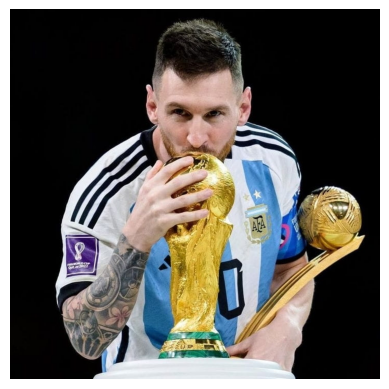

In [4]:
img = plt.imread('/content/drive/MyDrive/Dataset/HPC/wc.jpg')
h, w, _ = img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img)
plt.axis("off")
plt.show()

**Gaussian blur kernel**



In [5]:
KERNEL_SIZE = 7

def gaussian_kernel(kernel_size, sigma=1.5):
    ax = np.arange(kernel_size) - kernel_size // 2
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)
    g /= g.sum()
    return g
gaussian_filter = gaussian_kernel(KERNEL_SIZE)

**Example blur filter**

In [6]:
ex_blur_filter = np.array([
    [0, 0, 1, 2, 1, 0, 0],
    [0, 3, 13, 22, 13, 3, 0],
    [1, 13, 59, 97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59, 97, 59, 13, 1],
    [0, 3, 13, 22, 13, 3, 0],
    [0, 0, 1, 2, 1, 0, 0]
], dtype=np.float32)

print(ex_blur_filter.sum())
normalized_ex_blur_filter = ex_blur_filter / ex_blur_filter.sum()
print(normalized_ex_blur_filter.sum())

1003.0
1.0


In [7]:
N_RUNS = 10

**CPU Computation**

In [ ]:
def blur_cpu(input, filter):
  h, w, _ = input.shape
  filter_size = filter.shape[0]
  half_filter_size = filter_size // 2
  output = np.zeros((h, w, 3), np.uint8)

  for y in range(h):
    for x in range(w):
      for c in range(3):
        weighted_sum = 0.0
        for i in range(filter_size):
          yy = min(max(y + i - half_filter_size, 0), h - 1)
          for j in range(filter_size):
             xx = min(max(x + j - half_filter_size, 0), w - 1)
             weighted_sum += input[yy, xx, c] * filter[i, j]
        output[y, x, c] = np.uint8(weighted_sum)
  return output

def cpu_time(img, filter, n_runs):

  blur_cpu(img, gaussian_filter)

  times = []
  for i in range(N_RUNS):
      start = time.time()
      blurred_cpu = blur_cpu(img, gaussian_filter)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_cpu_t, std_cpu_t = np.mean(times), np.std(times)
  print(f"CPU time: {mean_cpu_t:.4f}s ± {std_cpu_t}s (mean of {N_RUNS} runs)")
  return blurred_cpu, times


Using example blur kernel

Run  1: 61.3834s
CPU time: 61.3834s ± 0.0s (mean of 1 runs)


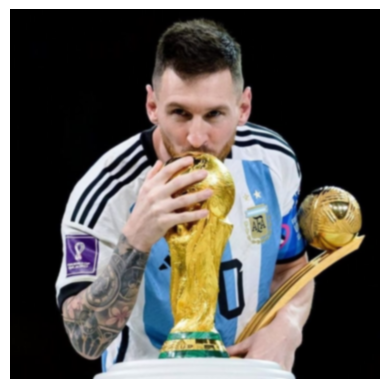

In [ ]:
blurred_cpu_ex_filt, _ = cpu_time(img, normalized_ex_blur_filter, N_RUNS)

plt.imshow(blurred_cpu_ex_filt)
plt.axis("off")
plt.savefig("blurred_cpu_example_filter.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

Using Gaussian kernel

Run  1: 64.3854s
CPU time: 64.3854s ± 0.0s (mean of 1 runs)


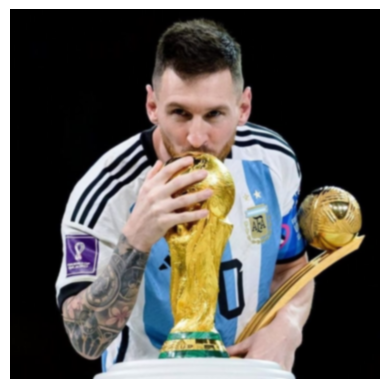

In [ ]:
blurred_cpu_gauss_filt, _ = cpu_time(img, gaussian_filter, N_RUNS)

plt.imshow(blurred_cpu_gauss_filt)
plt.axis("off")
plt.savefig("blurred_cpu_gauss_filter.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

**GPU computation**

Without shared memory kernel

In [8]:
@cuda.jit
def blur_gpu_global_kernel(input, output, filter):
  h, w, _ = input.shape
  filter_size = filter.shape[0]
  half_filter_size = filter_size // 2
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if tidx >= w or tidy >= h:
    return

  for c in range(3):
    weighted_sum = 0.0
    for i in range(filter_size):
      yy = min(max(tidy + i - half_filter_size, 0), h-1)
      for j in range(filter_size):
        xx = min(max(tidx + j - half_filter_size, 0), w - 1)
        weighted_sum += input[yy, xx, c] * filter[i, j]
    output[tidy, tidx, c] = np.uint8(weighted_sum)


Shared memory kernel

In [9]:
@cuda.jit
def blur_gpu_shared_kernel(input, output, filter):
  h, w, _ = input.shape
  filter_size = filter.shape[0]
  half_filter_size = filter_size // 2
  filter_shared = cuda.shared.array((7, 7), np.float32)
  if cuda.threadIdx.x < filter_size and cuda.threadIdx.y < filter_size:
    filter_shared[cuda.threadIdx.y, cuda.threadIdx.x] = filter[cuda.threadIdx.y, cuda.threadIdx.x]
  cuda.syncthreads()

  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if tidx >= w or tidy >= h:
    return

  for c in range(3):
    weighted_sum = 0.0
    for i in range(filter_size):
      yy = min(max(tidy + i - half_filter_size, 0), h-1)
      for j in range(filter_size):
        xx = min(max(tidx + j - half_filter_size, 0), w - 1)
        weighted_sum += input[yy, xx, c] * filter_shared[i, j]
    output[tidy, tidx, c] = np.uint8(weighted_sum)


In [10]:
def blur_gpu(input, kernel, blockSize, filter):
  h, w, _ = input.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  input_gpu = cuda.to_device(input)
  blurred_gpu = cuda.device_array((h, w, 3), np.uint8)
  kernel[gridSize, blockSize](input_gpu, blurred_gpu, filter)
  host_blurred_gpu = blurred_gpu.copy_to_host()
  return host_blurred_gpu

def gpu_time(img, kernel, blockSize, filter, n_runs):

  blur_gpu(img, kernel, blockSize, gaussian_filter)

  times = []
  for i in range(n_runs):
      start = time.time()
      blurred_gpu_img = blur_gpu(img, kernel, blockSize, gaussian_filter)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_t, std_t = np.mean(times), np.std(times)
  print(f"\nGPU time with 2D block size = {blockSize}: {mean_t:.4f}s ± {std_t:.4f}s (mean of {N_RUNS} runs)")

  return blurred_gpu_img, mean_t, std_t

In [11]:
blockSize = (32, 32)

GPU without shared memory computation

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:1089: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


Run  1: 0.0062s
Run  2: 0.0061s
Run  3: 0.0058s
Run  4: 0.0058s
Run  5: 0.0072s
Run  6: 0.0058s
Run  7: 0.0057s
Run  8: 0.0058s
Run  9: 0.0057s
Run 10: 0.0071s

GPU time with 2D block size = (32, 32): 0.0061s ± 0.0005s (mean of 10 runs)
Run  1: 0.0057s
Run  2: 0.0057s
Run  3: 0.0058s
Run  4: 0.0057s
Run  5: 0.0071s
Run  6: 0.0057s
Run  7: 0.0057s
Run  8: 0.0057s
Run  9: 0.0083s
Run 10: 0.0071s

GPU time with 2D block size = (32, 32): 0.0063s ± 0.0009s (mean of 10 runs)


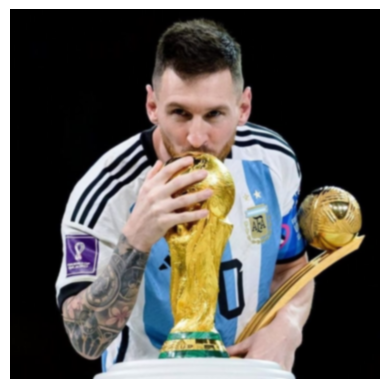

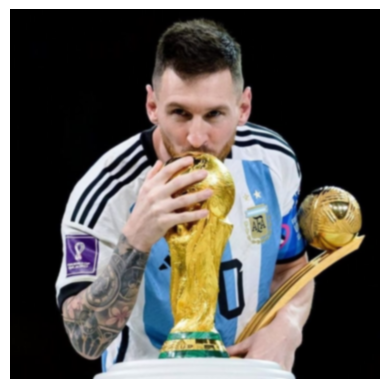

In [ ]:
blurred_gpu_global_ef_img, _ = gpu_time(img, blur_gpu_global_kernel, blockSize, normalized_ex_blur_filter, N_RUNS)
blurred_gpu_global_gf_img, _ = gpu_time(img, blur_gpu_global_kernel, blockSize, gaussian_filter, N_RUNS)

plt.imshow(blurred_gpu_global_ef_img)
plt.axis("off")
plt.savefig(f"blurred_gpu_global_e.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

plt.imshow(blurred_gpu_global_gf_img)
plt.axis("off")
plt.savefig(f"blurred_gpu_global_g.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

GPU with shared memory computation

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:1089: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


Run  1: 0.0058s
Run  2: 0.0056s
Run  3: 0.0053s
Run  4: 0.0053s
Run  5: 0.0052s
Run  6: 0.0067s
Run  7: 0.0052s
Run  8: 0.0052s
Run  9: 0.0051s
Run 10: 0.0051s

GPU time with 2D block size = (32, 32): 0.0055s ± 0.0005s (mean of 10 runs)
Run  1: 0.0051s
Run  2: 0.0051s
Run  3: 0.0051s
Run  4: 0.0051s
Run  5: 0.0052s
Run  6: 0.0076s
Run  7: 0.0066s
Run  8: 0.0052s
Run  9: 0.0054s
Run 10: 0.0054s

GPU time with 2D block size = (32, 32): 0.0056s ± 0.0008s (mean of 10 runs)


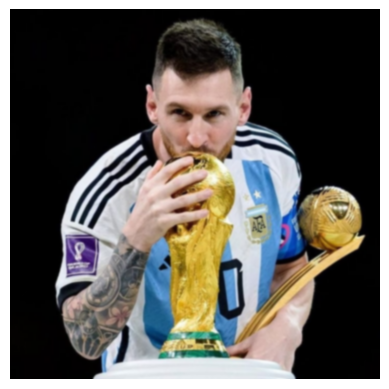

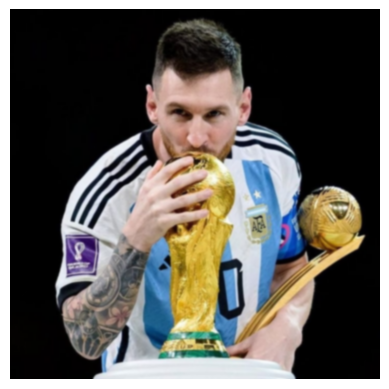

In [ ]:
blurred_gpu_shared_ef_img, _ = gpu_time(img, blur_gpu_shared_kernel, blockSize, normalized_ex_blur_filter, N_RUNS)
blurred_gpu_shared_gf_img, _ = gpu_time(img, blur_gpu_shared_kernel, blockSize, gaussian_filter, N_RUNS)

plt.imshow(blurred_gpu_shared_ef_img)
plt.axis("off")
plt.savefig(f"blurred_gpu_shared_ef.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

plt.imshow(blurred_gpu_shared_gf_img)
plt.axis("off")
plt.savefig(f"blurred_gpu_shared_gf.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

**Experimenting different 2D block size**

Run  1: 0.0056s
Run  2: 0.0056s
Run  3: 0.0054s
Run  4: 0.0054s
Run  5: 0.0072s
Run  6: 0.0054s
Run  7: 0.0054s
Run  8: 0.0054s
Run  9: 0.0054s
Run 10: 0.0067s

GPU time with 2D block size = (8, 8): 0.0058s ± 0.0006s (mean of 10 runs)
Run  1: 0.0054s
Run  2: 0.0054s
Run  3: 0.0055s
Run  4: 0.0056s
Run  5: 0.0068s
Run  6: 0.0055s
Run  7: 0.0055s
Run  8: 0.0055s
Run  9: 0.0054s
Run 10: 0.0067s

GPU time with 2D block size = (8, 8): 0.0057s ± 0.0005s (mean of 10 runs)
Run  1: 0.0054s
Run  2: 0.0054s
Run  3: 0.0054s
Run  4: 0.0054s
Run  5: 0.0056s
Run  6: 0.0044s
Run  7: 0.0047s
Run  8: 0.0046s
Run  9: 0.0046s
Run 10: 0.0059s

GPU time with 2D block size = (8, 16): 0.0051s ± 0.0005s (mean of 10 runs)
Run  1: 0.0043s
Run  2: 0.0043s
Run  3: 0.0044s
Run  4: 0.0044s
Run  5: 0.0056s
Run  6: 0.0051s
Run  7: 0.0045s
Run  8: 0.0043s
Run  9: 0.0042s
Run 10: 0.0056s

GPU time with 2D block size = (8, 16): 0.0047s ± 0.0005s (mean of 10 runs)
Run  1: 0.0043s
Run  2: 0.0043s
Run  3: 0.0043s
Run  4: 0.

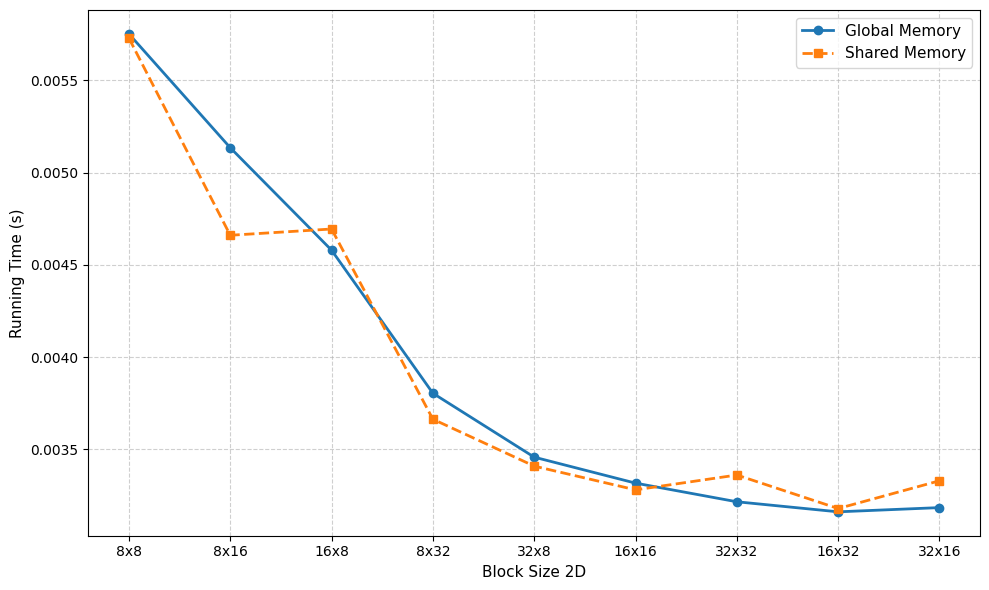

In [16]:
BLOCK_SIZE_2D = [(8,8), (8, 16), (16,8), (8, 32), (32, 8), (16, 16), (32, 32), (16, 32), (32, 16)]

means_global, stds_global = [], []
means_shared, stds_shared = [], []

for blockSize in BLOCK_SIZE_2D:
    _, mean_g, std_g = gpu_time(img, blur_gpu_global_kernel, blockSize, gaussian_filter, N_RUNS)
    _, mean_s, std_s = gpu_time(img, blur_gpu_shared_kernel, blockSize, gaussian_filter, N_RUNS)

    means_global.append(mean_g)
    stds_global.append(std_g)
    means_shared.append(mean_s)
    stds_shared.append(std_s)

labels = [f"{x}x{y}" for x, y in BLOCK_SIZE_2D]

for label, mg, ms in zip(labels, means_global, means_shared):
    print(f"Block size: {label} | {mg:.4f} | {ms:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(labels, means_global, marker="o", linewidth=2, linestyle="-", label="Global Memory")
plt.plot(labels, means_shared, marker="s", linewidth=2, linestyle="--", label="Shared Memory")

plt.xlabel("Block Size 2D", fontsize=11)
plt.ylabel("Running Time (s)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("share_vs_global_2d_different.png", dpi=150, bbox_inches="tight")
plt.show()